In [1]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [ ]:
# https://github.com/moshi4/pyCirclize

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_example_tree_file
from Bio import Phylo

In [5]:
phylogeny = Phylo.read(r"../../data/chapter2/uphylomaker/collab_fineroots_log_995_species_means_5states.tre", format="newick")

In [8]:
phylogeny.total_branch_length()

31862.196965946

In [9]:
phylogeny.count_terminals() # tips are called terminals here

995

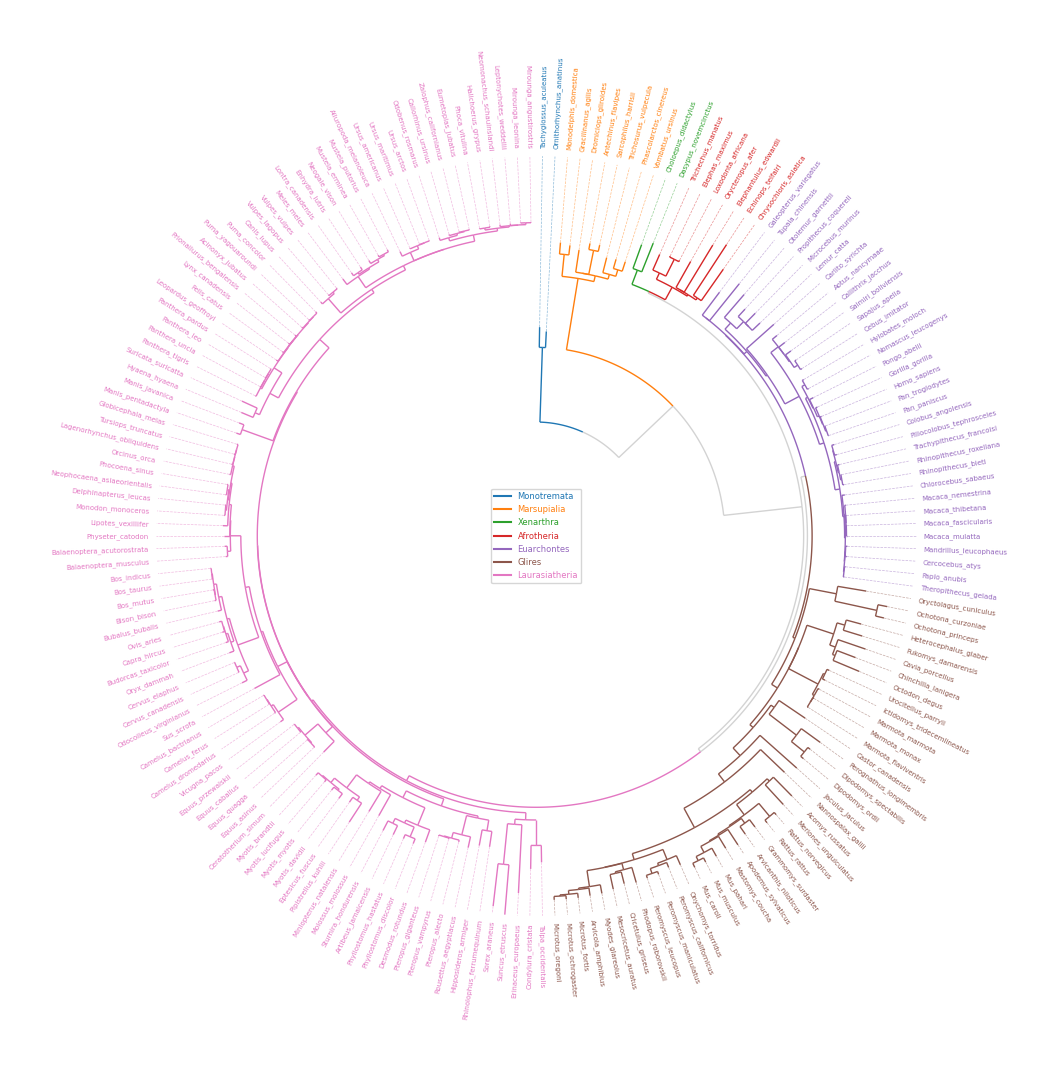

In [16]:
# Initialize Circos from phylogenetic tree
tree_file = load_example_tree_file("large_example.nwk")
circos, tv = Circos.initialize_from_tree(tree_file, r_lim=(30, 100), leaf_label_size=5, line_kws=dict(color="lightgrey", lw=1.0))

# Define group-species dict for tree annotation
# In this example, set minimum species list to specify group's MRCA node
group_name2species_list = dict(
    Monotremata=["Tachyglossus_aculeatus", "Ornithorhynchus_anatinus"],
    Marsupialia=["Monodelphis_domestica", "Vombatus_ursinus"],
    Xenarthra=["Choloepus_didactylus", "Dasypus_novemcinctus"],
    Afrotheria=["Trichechus_manatus", "Chrysochloris_asiatica"],
    Euarchontes=["Galeopterus_variegatus", "Theropithecus_gelada"],
    Glires=["Oryctolagus_cuniculus", "Microtus_oregoni"],
    Laurasiatheria=["Talpa_occidentalis", "Mirounga_leonina"],
)

# Set tree line color & label color
ColorCycler.set_cmap("tab10")
group_name2color = {name: ColorCycler() for name in group_name2species_list.keys()}
for group_name, species_list in group_name2species_list.items():
    color = group_name2color[group_name]
    tv.set_node_line_props(species_list, color=color, apply_label_color=True)

# Plot figure & set legend on center
fig = circos.plotfig()
fig.set_size_inches(10, 10)
circos.ax.legend(handles=[Line2D([], [], label=n, color=c) for n, c in group_name2color.items()], labelcolor=group_name2color.values(), fontsize=6, loc="center", bbox_to_anchor=(0.5, 0.5))

# plt.show()
plt.savefig(r"./dummyphylogeny.png", dpi=800)

In [ ]:
# http://www.phytools.org/Cordoba2017/ex/15/Plotting-methods.html